In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
# https://www.kaggle.com/datasets/lucidlenn/sloan-digital-sky-survey

View "PhotoObj" objid = Object Identifier ra = J2000 Right Ascension (r-band) dec = J2000 Declination (r-band) Right ascension (abbreviated RA) is the angular distance measured eastward along the celestial equator from the Sun at the March equinox to the hour circle of the point above the earth in question. When paired with declination (abbreviated dec), these astronomical coordinates specify the direction of a point on the celestial sphere (traditionally called in English the skies or the sky) in the equatorial coordinate system.

Source: https://en.wikipedia.org/wiki/Right_ascension

u = better of DeV/Exp magnitude fit g = better of DeV/Exp magnitude fit r = better of DeV/Exp magnitude fit i = better of DeV/Exp magnitude fit z = better of DeV/Exp magnitude fit The Thuan-Gunn astronomic magnitude system. u, g, r, i, z represent the response of the 5 bands of the telescope.

Further education: https://www.astro.umd.edu/~ssm/ASTR620/mags.html

run = Run Number rereun = Rerun Number camcol = Camera column field = Field number Run, rerun, camcol and field are features which describe a field within an image taken by the SDSS. A field is basically a part of the entire image corresponding to 2048 by 1489 pixels. A field can be identified by:

run number, which identifies the specific scan, the camera column, or "camcol," a number from 1 to 6, identifying the scanline within the run, and the field number. The field number typically starts at 11 (after an initial rampup time), and can be as large as 800 for particularly long runs. An additional number, rerun, specifies how the image was processed. View "SpecObj" specobjid = Object Identifier class = object class (galaxy, star or quasar object) The class identifies an object to be either a galaxy, star or quasar. This will be the response variable which we will be trying to predict.

redshift = Final Redshift plate = plate number mjd = MJD of observation fiberid = fiber ID

In [3]:
df = pd.read_csv("20-digitalskysurvey.csv")

In [4]:
df.head()

,objid,ra,dec,u,g,r,i,z,run,rerun,camcol,field,specobjid,class,redshift,plate,mjd,fiberid
0,1.237650e+18,183.531326,0.089693,19.47406,17.04240,15.94699,15.50342,15.22531,752,301,4,267,3.722360e+18,STAR,-0.000009,3306,54922,491
1,1.237650e+18,183.598370,0.135285,18.66280,17.21449,16.67637,16.48922,16.39150,752,301,4,267,3.638140e+17,STAR,-0.000055,323,51615,541
2,1.237650e+18,183.680207,0.126185,19.38298,18.19169,17.47428,17.08732,16.80125,752,301,4,268,3.232740e+17,GALAXY,0.123111,287,52023,513
3,1.237650e+18,183.870529,0.049911,17.76536,16.60272,16.16116,15.98233,15.90438,752,301,4,269,3.722370e+18,STAR,-0.000111,3306,54922,510
4,1.237650e+18,183.883288,0.102557,17.55025,16.26342,16.43869,16.55492,16.61326,752,301,4,269,3.722370e+18,STAR,0.000590,3306,54922,512


In [5]:
columns_to_drop = ["objid","specobjid","run","rerun","camcol","field"]

In [6]:
df.drop(columns_to_drop,axis=1, inplace=True)

In [7]:
df.head()

,ra,dec,u,g,r,i,z,class,redshift,plate,mjd,fiberid
0,183.531326,0.089693,19.47406,17.04240,15.94699,15.50342,15.22531,STAR,-0.000009,3306,54922,491
1,183.598370,0.135285,18.66280,17.21449,16.67637,16.48922,16.39150,STAR,-0.000055,323,51615,541
2,183.680207,0.126185,19.38298,18.19169,17.47428,17.08732,16.80125,GALAXY,0.123111,287,52023,513
3,183.870529,0.049911,17.76536,16.60272,16.16116,15.98233,15.90438,STAR,-0.000111,3306,54922,510
4,183.883288,0.102557,17.55025,16.26342,16.43869,16.55492,16.61326,STAR,0.000590,3306,54922,512


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   ra        10000 non-null  float64
 1   dec       10000 non-null  float64
 2   u         10000 non-null  float64
 3   g         10000 non-null  float64
 4   r         10000 non-null  float64
 5   i         10000 non-null  float64
 6   z         10000 non-null  float64
 7   class     10000 non-null  object 
 8   redshift  10000 non-null  float64
 9   plate     10000 non-null  int64  
 10  mjd       10000 non-null  int64  
 11  fiberid   10000 non-null  int64  
dtypes: float64(8), int64(3), object(1)
memory usage: 937.6+ KB


In [9]:
df['class'].value_counts()

class
GALAXY    4998
STAR      4152
QSO        850
Name: count, dtype: int64

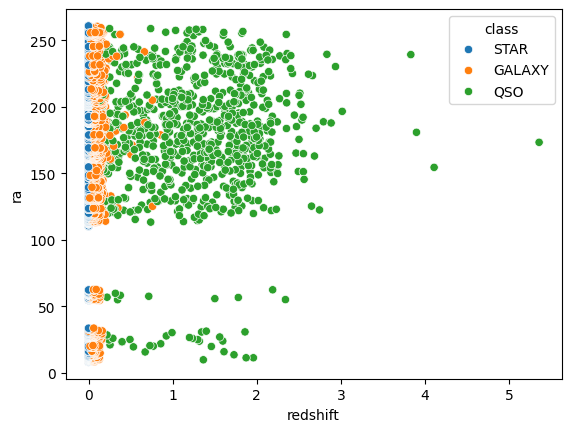

In [10]:
sns.scatterplot(data=df, x = 'redshift', y = 'ra', hue = 'class')
plt.show()

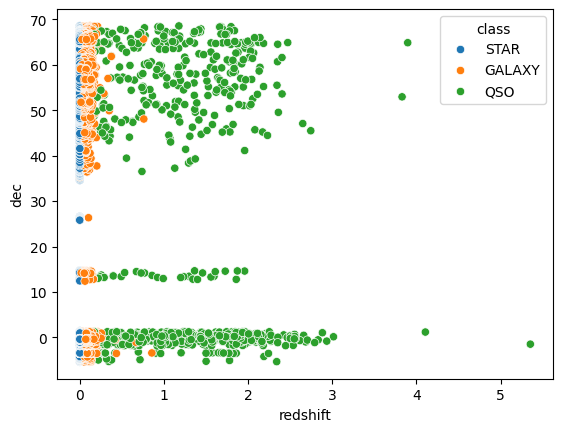

In [11]:
sns.scatterplot(data=df, x = 'redshift', y = 'dec', hue = 'class')
plt.show()

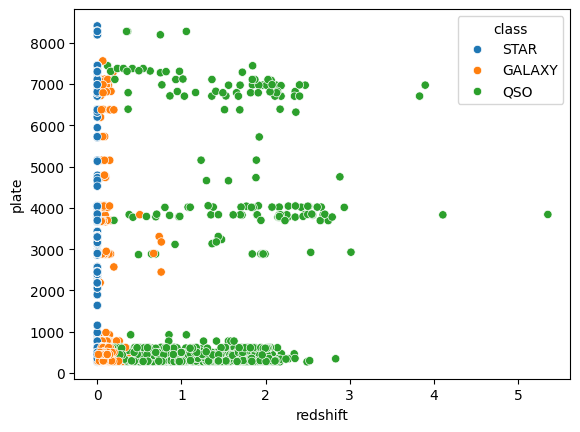

In [12]:
sns.scatterplot(data=df, x = 'redshift', y = 'plate', hue = 'class')
plt.show()

In [13]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['class'] = le.fit_transform(df['class'])

In [14]:
df['class'].value_counts()

class
0    4998
2    4152
1     850
Name: count, dtype: int64

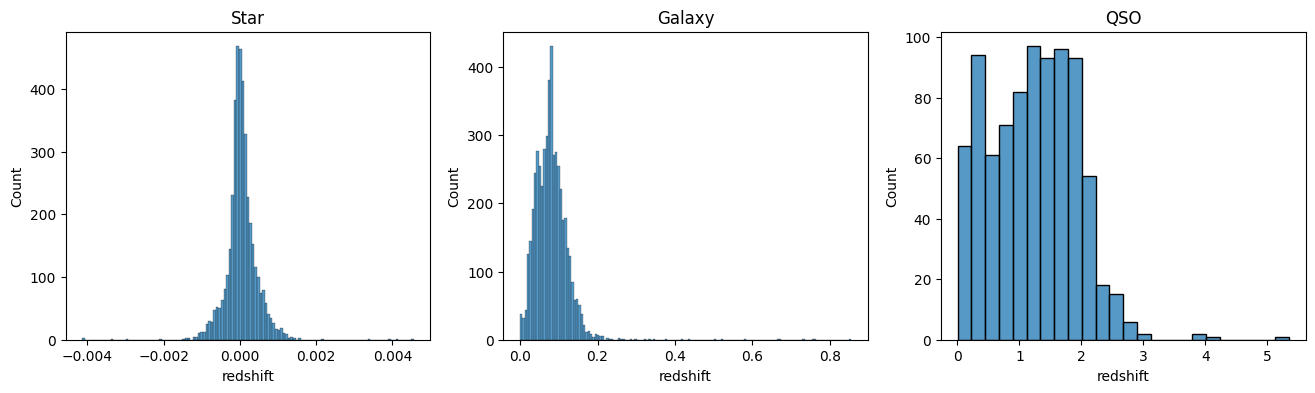

In [15]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(16,4))
ax = sns.histplot(df[df['class'] == 2].redshift, ax = axes[0])
ax.set_title('Star')
ax = sns.histplot(df[df['class'] == 0].redshift, ax = axes[1])
ax.set_title('Galaxy')
ax = sns.histplot(df[df['class'] == 1].redshift, ax = axes[2])
ax.set_title('QSO')
plt.show()

In [16]:
X = df.drop("class", axis=1)
y = df["class"]

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.33, random_state=15)

In [19]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [20]:
from xgboost import XGBClassifier

In [21]:
xgb = XGBClassifier(n_estimators = 100)
xgb.fit(X_train,y_train)
y_pred = xgb.predict(X_test)

In [22]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [23]:
print("accuracy_score: ", accuracy_score(y_test,y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test,y_pred))

accuracy_score:  0.9875757575757576
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1687
           1       0.95      0.93      0.94       271
           2       0.99      1.00      1.00      1342

    accuracy                           0.99      3300
   macro avg       0.98      0.97      0.98      3300
weighted avg       0.99      0.99      0.99      3300

[[1667   13    7]
 [  17  253    1]
 [   3    0 1339]]


In [24]:
params = {
    "n_estimators": [100,200,300,500],
    "learning_rate": [0.01, 0.1], # eta
    "max_depth": [5,8,12,20,30],
    "colsample_bytree": [0.3,0.4,0.5,0.8,1]
}

In [25]:
from sklearn.model_selection import GridSearchCV

In [26]:
grid = GridSearchCV(estimator=XGBClassifier(), param_grid=params, cv=5, n_jobs=-1)

In [27]:
grid.fit(X_train,y_train)

,estimator,"XGBClassifier...ree=None, ...)"
,param_grid,"{'colsample_bytree': [0.3, 0.4, ...], 'learning_rate': [0.01, 0.1], 'max_depth': [5, 8, ...], 'n_estimators': [100, 200, ...]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'multi:softprob'


In [29]:
grid.best_params_

{'colsample_bytree': 0.3,
 'learning_rate': 0.1,
 'max_depth': 5,
 'n_estimators': 500}

In [30]:
y_pred = grid.predict(X_test)

In [31]:
print("accuracy_score: ", accuracy_score(y_test,y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test,y_pred))

accuracy_score:  0.9884848484848485
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1687
           1       0.96      0.93      0.94       271
           2       0.99      1.00      1.00      1342

    accuracy                           0.99      3300
   macro avg       0.98      0.97      0.98      3300
weighted avg       0.99      0.99      0.99      3300

[[1669   11    7]
 [  18  252    1]
 [   1    0 1341]]
